# Imports

In [1]:
import torch
import numpy as np
import torch.nn as nn
import os, math, time
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, utils
from torchvision.utils import make_grid, save_image
from torchmetrics.image.fid import FrechetInceptionDistance

# PHASE 1

# Dataset

In [2]:
class CelebABlackBrown(Dataset):
    def __init__(self, root, split="train", download=False, transform=None, seed=42):
        super().__init__()
        self.dataset = datasets.CelebA(
            root=root,
            split=split,
            target_type="attr",
            download=download,
            transform=transform,
        )

        names = self.dataset.attr_names
        i_black = names.index("Black_Hair")
        i_brown = names.index("Brown_Hair")

        black = (self.dataset.attr[:, i_black] == 1)
        brown = (self.dataset.attr[:, i_brown] == 1)

        black_only = torch.where(black & ~brown)[0]
        brown_only = torch.where(brown & ~black)[0]

        g = torch.Generator().manual_seed(seed)
        n = min(len(black_only), len(brown_only))

        black_sel = black_only[torch.randperm(len(black_only), generator=g)[:n]]
        brown_sel = brown_only[torch.randperm(len(brown_only), generator=g)[:n]]

        chosen = torch.cat([black_sel, brown_sel], dim=0)
        chosen = chosen[torch.randperm(len(chosen), generator=g)]

        self.indices = chosen
        self.i_black = i_black
        self.i_brown = i_brown

        sel_attr = self.dataset.attr[self.indices]
        self.total_black = int((sel_attr[:, i_black] == 1).sum().item())
        self.total_brown = int((sel_attr[:, i_brown] == 1).sum().item())

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        img, attr = self.dataset[idx]
        c = torch.tensor([
            (attr[self.i_black] == 1),
            (attr[self.i_brown] == 1),
        ], dtype=torch.float32)
        return img, c

# Transform

In [3]:
transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),
])

# Train Data

In [4]:
batch_size = 64

In [ ]:
train_dataset = CelebABlackBrown(
    root=".",
    split="train",
    download=True,
    transform=transform,
    seed=42
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

# Statistics

In [6]:
print("Dataset size:", len(train_dataset))
print("Total Brown positives:", train_dataset.total_brown)
print("Total Black positives:", train_dataset.total_black)
print("Equal:", train_dataset.total_brown == train_dataset.total_black)

Dataset size: 64522
Total Brown positives: 32261
Total Black positives: 32261
Equal: True


In [7]:
print(len(train_dataset.dataset.attr_names))
print(train_dataset.dataset.attr_names)

41
['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young', '']


In [8]:
A = train_dataset.dataset.attr[train_dataset.indices]
print("Global unique values in attr:", sorted(int(x) for x in torch.unique(A).tolist()))

Global unique values in attr: [0, 1]


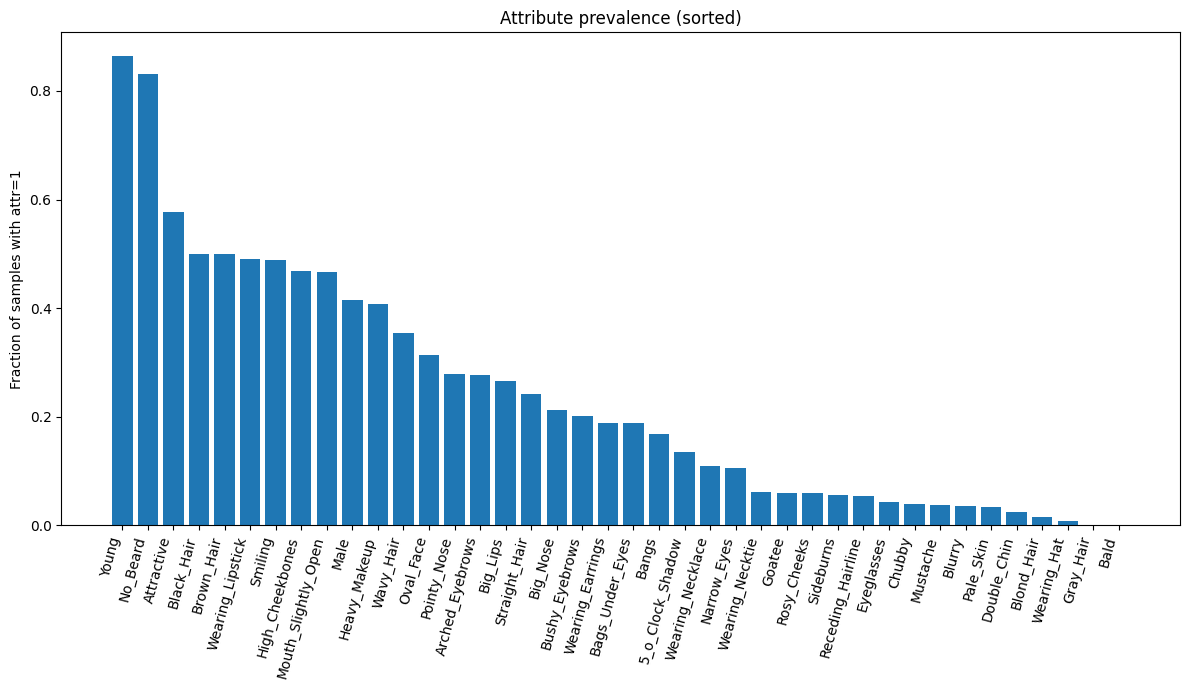

In [9]:
if isinstance(A, torch.Tensor):
    A = A.detach().cpu().numpy()
else:
    A = np.asarray(A)

pos_rate = A.mean(axis=0)
pos_count = A.sum(axis=0).astype(int)

names = getattr(train_dataset.dataset, "attr_names", None)
if names is None:
    names = [f"attr_{i}" for i in range(A.shape[1])]

order = np.argsort(pos_rate)[::-1]
pos_rate_sorted = pos_rate[order]
pos_count_sorted = pos_count[order]
names_sorted = [names[i] for i in order]

plt.figure(figsize=(12, 7))
plt.bar(range(len(names_sorted)), pos_rate_sorted)
plt.xticks(range(len(names_sorted)), names_sorted, rotation=75, ha="right")
plt.ylabel("Fraction of samples with attr=1")
plt.title("Attribute prevalence (sorted)")
plt.tight_layout()
plt.show()

# Plotting images

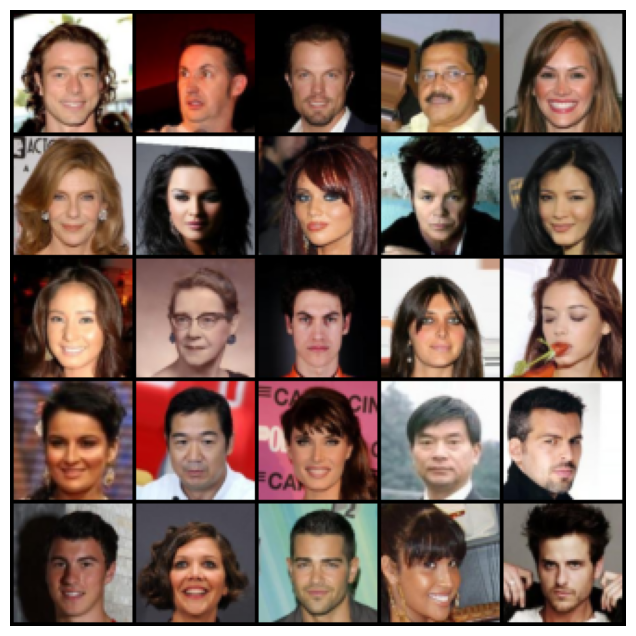

In [ ]:
images, y = next(iter(train_loader))
images = (images * 0.5) + 0.5
grid = utils.make_grid(images[:25], nrow=5, padding=2)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()

# WGAN

## Gradient Penalty

In [11]:
def gradient_penalty(critic, real, fake, device):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    scores = critic(x_hat)
    grad = torch.autograd.grad(
        outputs=scores,
        inputs=x_hat,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grad = grad.view(B, -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

## Generator

In [12]:
class Generator(nn.Module):
    def __init__(self, z_dim=128, img_ch=3, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, base*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*8, base*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(True),

            nn.ConvTranspose2d(base, img_ch, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)

## Critic

In [13]:
class Critic(nn.Module):
    def __init__(self, img_ch=3, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_ch, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*4, base*8, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)

## Fréchet Inception Distance

In [14]:
def to_fid_uint8(x):
    x = ((x + 1) / 2).clamp(0, 1)
    return (x * 255).to(torch.uint8)

In [15]:
def make_fid(device):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    return fid

In [ ]:
@torch.no_grad()
def compute_fid(G, train_loader, fid, device, z_dim,
                fid_num_batches=50, gen_batches_for_fid=50, batch_size_for_fid=64):
    if fid is None:
        return None
    fid.reset()

    for i, batch in enumerate(train_loader):
        real = batch[0] if isinstance(batch, (list, tuple)) else batch
        real = real.to(device)
        fid.update(to_fid_uint8(real), real=True)
        if i + 1 >= fid_num_batches:
            break

    G.eval()
    for _ in range(gen_batches_for_fid):
        z = torch.randn(batch_size_for_fid, z_dim, 1, 1, device=device)
        fake = G(z)
        fid.update(to_fid_uint8(fake), real=False)
    G.train()

    return float(fid.compute().item())

## Plotting images, Saving model, Showing loss curves  

In [17]:
def save_grid(G, fixed_z, epoch, img_dir):
    G.eval()
    with torch.no_grad():
        fake = G(fixed_z)
        grid = make_grid(fake, nrow=5, padding=2, normalize=True, value_range=(-1, 1))
        path = os.path.join(img_dir, f"epoch_{epoch:04d}.png")
        save_image(grid, path)
    G.train()
    print(f"Saved sample grid: {path}")

In [18]:
def save_best_ckpt(path, epoch, G, D, optG, optD, best_fid, z_dim):
    torch.save({
        "epoch": epoch,
        "G_state": G.state_dict(),
        "D_state": D.state_dict(),
        "optG": optG.state_dict(),
        "optD": optD.state_dict(),
        "best_fid": best_fid,
        "z_dim": z_dim,
    }, path)

In [19]:
def plot_curves(out_dir, g_losses, d_losses, fid_epochs, fid_scores):
    plt.figure()
    plt.plot(g_losses, label="Generator loss")
    plt.plot(d_losses, label="Critic loss")
    plt.legend()
    plt.title("WGAN-GP Losses")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.savefig(os.path.join(out_dir, "losses.png"), dpi=150)
    plt.show()

    if fid_scores is not None and len(fid_scores) > 0:
        plt.figure()
        plt.plot(fid_epochs, fid_scores, marker="o")
        plt.title("FID over epochs")
        plt.xlabel("Epoch")
        plt.ylabel("FID (lower is better)")
        plt.savefig(os.path.join(out_dir, "fid.png"), dpi=150)
        plt.show()

# Training

## Device

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## Model, Optimizers, parameters

In [ ]:
out_dir="wgan_gp_runs"
z_dim=128
lr=2e-4
betas=(0.0, 0.9)
n_critic=5
lambda_gp=10.0
max_epochs=30

In [22]:
G = Generator(z_dim=z_dim).to(device)
D = Critic().to(device)
optG = optim.Adam(G.parameters(), lr=lr, betas=betas)
optD = optim.Adam(D.parameters(), lr=lr, betas=betas)

## Output Directories

In [23]:
os.makedirs(out_dir, exist_ok=True)
img_dir = os.path.join(out_dir, "samples")
ckpt_dir = os.path.join(out_dir, "checkpoints")
os.makedirs(img_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

## Train

### Train Critic

In [ ]:
def train_critic(G, D, B, real, optD, z_dim, lambda_gp, device):
    z = torch.randn(B, z_dim, 1, 1, device=device)
    fake = G(z).detach()

    d_real = D(real).mean()
    d_fake = D(fake).mean()
    gp = gradient_penalty(D, real, fake, device)
    lossD = -(d_real - d_fake) + lambda_gp * gp

    optD.zero_grad(set_to_none=True)
    lossD.backward()
    optD.step()
    return lossD

### Train Generator

In [25]:
def train_generator(G, D, B, optG, z_dim, device):
    z = torch.randn(B, z_dim, 1, 1, device=device)
    fake = G(z)
    lossG = -D(fake).mean()

    optG.zero_grad(set_to_none=True)
    lossG.backward()
    optG.step()
    return lossG

## Train Loop

In [ ]:
def train_wgan_gp(
    G,
    D,
    train_loader,
    device,
    img_dir,
    ckpt_dir,
    out_dir,
    optD,
    optG,
    n_critic=5,
    z_dim=128,
    lambda_gp=10.0,
    max_epochs=200,
    show_every=5,
    fid_every=5,
    fid_num_batches=50,
    gen_batches_for_fid=50,
    batch_size_for_fid=64,
    divergence_patience=4,
    divergence_margin=10.0,
):

    fixed_z = torch.randn(25, z_dim, 1, 1, device=device)
    fid = make_fid(device)

    best_fid = float("inf")
    bad_fid_streak = 0
    g_losses, d_losses, fid_scores, fid_epochs = [], [], [], []

    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    save_grid(G, fixed_z, epoch=0, img_dir=img_dir)

    stop = False

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()

        loader_iter = iter(train_loader)

        for _ in range(len(train_loader)):
            for _ in range(n_critic):
                try:
                    batch = next(loader_iter)
                except StopIteration:
                    loader_iter = iter(train_loader)
                    batch = next(loader_iter)

                real = batch[0] if isinstance(batch, (list, tuple)) else batch
                real = real.to(device)
                B = real.size(0)

                lossD = train_critic(G, D, B, real, optD, z_dim, lambda_gp, device)

            lossG = train_generator(G, D, B, optG, z_dim, device)

            d_losses.append(float(lossD.item()))
            g_losses.append(float(lossG.item()))

            if not (math.isfinite(d_losses[-1]) and math.isfinite(g_losses[-1])):
                print("🛑 Divergence detected (NaN/Inf loss). Stopping.")
                stop = True
                break

        print(
            f"Epoch {epoch}/{max_epochs}  "
            f"lossD={d_losses[-1]:.4f}  lossG={g_losses[-1]:.4f}  "
            f"time={time.time()-t0:.1f}s"
        )

        if stop:
            break

        if epoch % show_every == 0:
            save_grid(G, fixed_z, epoch, img_dir)

        if fid is not None and epoch % fid_every == 0:
            score = compute_fid(
                G, train_loader, fid, device, z_dim,
                fid_num_batches=fid_num_batches,
                gen_batches_for_fid=gen_batches_for_fid,
                batch_size_for_fid=batch_size_for_fid
            )
            fid_scores.append(score)
            fid_epochs.append(epoch)
            print(f"FID @ epoch {epoch}: {score:.3f}")

            if score < best_fid:
                best_fid = score
                bad_fid_streak = 0
                ckpt_path = os.path.join(ckpt_dir, "best.pt")
                save_best_ckpt(ckpt_path, epoch, G, D, optG, optD, best_fid, z_dim)
                print(f"✅ Saved BEST checkpoint (FID={best_fid:.3f}) -> {ckpt_path}")
            else:
                bad_fid_streak = bad_fid_streak + 1 if score > best_fid + divergence_margin else 0
                if bad_fid_streak >= divergence_patience:
                    print(f"🛑 Stopping: FID worsened by >{divergence_margin} for {divergence_patience} evals.")
                    break

    plot_curves(out_dir, g_losses, d_losses, fid_epochs, fid_scores)
    print("Done. Best FID:", best_fid)
    print("Best checkpoint:", os.path.join(ckpt_dir, "best.pt"))
    return G, D

In [ ]:
train_wgan_gp(G, D, train_loader, device, img_dir, ckpt_dir, out_dir, optD, optG, n_critic, z_dim, lambda_gp, max_epochs)

Saved sample grid: wgan_gp_runs\samples\epoch_0000.png


# PHASE 2

## Dataset

In [ ]:
class CelebABlackBrownSmiling(Dataset):
    def __init__(self, root, split="train", download=False, transform=None, seed=42):
        super().__init__()
        self.dataset = datasets.CelebA(
            root=root,
            split=split,
            target_type="attr",
            download=download,
            transform=transform,
        )

        names = self.dataset.attr_names
        i_black = names.index("Black_Hair")
        i_brown = names.index("Brown_Hair")
        i_smile = names.index("Smiling")

        black = (self.dataset.attr[:, i_black] == 1)
        brown = (self.dataset.attr[:, i_brown] == 1)

        black_only = torch.where(black & ~brown)[0]
        brown_only = torch.where(brown & ~black)[0]

        g = torch.Generator().manual_seed(seed)

        n = min(len(black_only), len(brown_only))
        black_sel = black_only[torch.randperm(len(black_only), generator=g)[:n]]
        brown_sel = brown_only[torch.randperm(len(brown_only), generator=g)[:n]]

        chosen = torch.cat([black_sel, brown_sel], dim=0)
        chosen = chosen[torch.randperm(len(chosen), generator=g)]

        self.indices = chosen
        self.i_black = i_black
        self.i_brown = i_brown
        self.i_smile = i_smile

        sel_attr = self.dataset.attr[self.indices]
        self.total_black = int((sel_attr[:, i_black] == 1).sum().item())
        self.total_brown = int((sel_attr[:, i_brown] == 1).sum().item())
        self.total_smile = int((sel_attr[:, i_smile] == 1).sum().item())

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        img, attr = self.dataset[idx]
        c = torch.tensor([
            (attr[self.i_black] == 1),
            (attr[self.i_brown] == 1),
            (attr[self.i_smile] == 1),
        ], dtype=torch.float32)
        return img, c

# Train data

In [ ]:
train_dataset = CelebABlackBrownSmiling(
    root="./data",
    split="train",
    download=True,
    transform=transform,
    seed=42
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

## Statistics

In [ ]:
print("Dataset size:", len(train_dataset))
print("Total Brown positives:", train_dataset.total_brown)
print("Total Black positives:", train_dataset.total_black)
print("Total Smiling positives:", train_dataset.total_smile)
print("Equal:", train_dataset.total_brown == train_dataset.total_black)

In [ ]:
A = train_dataset.dataset.attr[train_dataset.indices]
if isinstance(A, torch.Tensor):
    A = A.detach().cpu().numpy()
else:
    A = np.asarray(A)

pos_rate = A.mean(axis=0)
pos_count = A.sum(axis=0).astype(int)

names = getattr(train_dataset.dataset, "attr_names", None)
if names is None:
    names = [f"attr_{i}" for i in range(A.shape[1])]

order = np.argsort(pos_rate)[::-1]
pos_rate_sorted = pos_rate[order]
pos_count_sorted = pos_count[order]
names_sorted = [names[i] for i in order]

plt.figure(figsize=(12, 7))
plt.bar(range(len(names_sorted)), pos_rate_sorted)
plt.xticks(range(len(names_sorted)), names_sorted, rotation=75, ha="right")
plt.ylabel("Fraction of samples with attr=1")
plt.title("Attribute prevalence (sorted)")
plt.tight_layout()
plt.show()

# Plotting images

In [ ]:
images, c = next(iter(train_loader))
images = (images * 0.5) + 0.5
grid = utils.make_grid(images[:25], nrow=5, padding=2)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()

## Gradient Penalty

In [ ]:
def gradient_penalty(critic, real, fake, c, device):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    scores = critic(x_hat, c)
    grad = torch.autograd.grad(
        outputs=scores,
        inputs=x_hat,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grad = grad.view(B, -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

# Generator Concat

In [ ]:
class Generator_Concat(nn.Module):
    def __init__(self, z_dim=128, c_dim=3, img_ch=3, base=64):
        super().__init__()
        in_dim = z_dim + c_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_dim, base*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*8, base*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(True),

            nn.ConvTranspose2d(base, img_ch, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z, c):
        c = c.view(c.size(0), c.size(1), 1, 1)
        x = torch.cat([z, c], dim=1)
        return self.net(x)

# Critic Concat

In [ ]:
class Critic_Concat(nn.Module):
    def __init__(self, c_dim=3, img_ch=3, base=64):
        super().__init__()
        self.c_dim = c_dim
        in_ch = img_ch + c_dim
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*4, base*8, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x, c):
        B, _, H, W = x.shape
        c_map = c.view(B, self.c_dim, 1, 1).expand(B, self.c_dim, H, W)
        x2 = torch.cat([x, c_map], dim=1)
        return self.net(x2).view(-1)

# Generator Inject

In [ ]:
class FiLM(nn.Module):
    def __init__(self, c_dim, n_channels):
        super().__init__()
        self.to_gb = nn.Sequential(
            nn.Linear(c_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 2 * n_channels),
        )

    def forward(self, h, c):
        gb = self.to_gb(c)
        gamma, beta = gb.chunk(2, dim=1)
        gamma = gamma.view(-1, h.size(1), 1, 1)
        beta  = beta.view(-1, h.size(1), 1, 1)
        return (1 + gamma) * h + beta


class GeneratorFiLM(nn.Module):
    def __init__(self, z_dim=128, c_dim=3, img_ch=3, base=64):
        super().__init__()
        self.deconv1 = nn.ConvTranspose2d(z_dim, base*8, 4, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(base*8); self.film1 = FiLM(c_dim, base*8)

        self.deconv2 = nn.ConvTranspose2d(base*8, base*4, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(base*4); self.film2 = FiLM(c_dim, base*4)

        self.deconv3 = nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(base*2); self.film3 = FiLM(c_dim, base*2)

        self.deconv4 = nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False)
        self.bn4 = nn.BatchNorm2d(base); self.film4 = FiLM(c_dim, base)

        self.deconv5 = nn.ConvTranspose2d(base, img_ch, 4, 2, 1, bias=False)

        self.act = nn.ReLU(True)
        self.tanh = nn.Tanh()

    def forward(self, z, c):
        h = self.deconv1(z); h = self.bn1(h); h = self.film1(h, c); h = self.act(h)
        h = self.deconv2(h); h = self.bn2(h); h = self.film2(h, c); h = self.act(h)
        h = self.deconv3(h); h = self.bn3(h); h = self.film3(h, c); h = self.act(h)
        h = self.deconv4(h); h = self.bn4(h); h = self.film4(h, c); h = self.act(h)
        h = self.deconv5(h)
        return self.tanh(h)

# Critic Inject

In [ ]:
class CriticProj(nn.Module):
    def __init__(self, c_dim=3, img_ch=3, base=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(img_ch, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*4, base*8, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.lin = nn.Linear(base*8, 1)

        self.embed = nn.Sequential(
            nn.Linear(c_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, base*8),
        )

    def forward(self, x, c):
        h = self.features(x)
        h = self.pool(h).view(x.size(0), -1)

        out = self.lin(h).view(-1)
        e = self.embed(c)
        proj = (h * e).sum(dim=1)

        return out + proj

## Fréchet Inception Distance

In [ ]:
@torch.no_grad()
def compute_fid(G, train_loader, fid, device, z_dim,
                fid_num_batches=50, gen_batches_for_fid=50):
    if fid is None:
        return None
    fid.reset()

    for i, (real, _) in enumerate(train_loader):
        real = real.to(device)
        fid.update(to_fid_uint8(real), real=True)
        if i + 1 >= fid_num_batches:
            break

    G.eval()
    loader_iter = iter(train_loader)
    for _ in range(gen_batches_for_fid):
        try:
            _, c = next(loader_iter)
        except StopIteration:
            loader_iter = iter(train_loader)
            _, c = next(loader_iter)

        c = c.to(device).float()
        B = c.size(0)
        z = torch.randn(B, int(z_dim), 1, 1, device=device)
        fake = G(z, c)
        fid.update(to_fid_uint8(fake), real=False)
    G.train()

    return float(fid.compute().item())

# Plotting Images

In [ ]:
def save_grid(G, fixed_z, epoch, img_dir, device):
    G.eval()
    with torch.no_grad():
        c_list = [
            [1,0,0],
            [1,0,1],
            [0,1,0],
            [0,1,1],
            [1,1,0],
            [1,1,1]
        ]
        k = 5

        assert fixed_z.size(0) >= len(c_list) * k

        imgs = []
        for j, c0 in enumerate(c_list):
            z = fixed_z[j*k:(j+1)*k]
            c = torch.tensor(c0, dtype=torch.float32, device=device).view(1, 3).repeat(k, 1)
            fake = G(z, c)
            imgs.append(fake)

        fake_all = torch.cat(imgs, dim=0)
        grid = make_grid(fake_all, nrow=k, padding=2, normalize=True, value_range=(-1, 1))
        path = os.path.join(img_dir, f"epoch_{epoch:04d}_cond.png")
        save_image(grid, path)

    G.train()
    print(f"Saved sample grid: {path}")

# Train

## Train critic

In [ ]:
def train_critic(G, D, real, c, optD, z_dim, lambda_gp, device):
    B = real.size(0)
    z = torch.randn(B, int(z_dim), 1, 1, device=device)
    fake = G(z, c).detach()

    d_real = D(real, c).mean()
    d_fake = D(fake, c).mean()
    gp = gradient_penalty(D, real, fake, c, device)

    lossD = -(d_real - d_fake) + lambda_gp * gp

    optD.zero_grad(set_to_none=True)
    lossD.backward()
    optD.step()
    return lossD

## Train generator

In [ ]:
def train_generator(G, D, c, optG, z_dim, device):
    B = c.size(0)
    z = torch.randn(B, int(z_dim), 1, 1, device=device)
    fake = G(z, c)

    lossG = -D(fake, c).mean()

    optG.zero_grad(set_to_none=True)
    lossG.backward()
    optG.step()
    return lossG

# Train Loop

In [ ]:
def train_wgan_gp(
    G,
    D,
    train_loader,
    device,
    img_dir,
    ckpt_dir,
    out_dir,
    optD,
    optG,
    n_critic=5,
    z_dim=128,
    lambda_gp=10.0,
    max_epochs=200,
    show_every=5,
    fid_every=5,
    fid_num_batches=50,
    gen_batches_for_fid=50,
    divergence_patience=4,
    divergence_margin=10.0,
):
    z_dim = int(z_dim)

    fixed_z = torch.randn(20, z_dim, 1, 1, device=device)

    fid = make_fid(device)

    best_fid = float("inf")
    bad_fid_streak = 0
    g_losses, d_losses, fid_scores, fid_epochs = [], [], [], []

    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(out_dir, exist_ok=True)

    save_grid(G, fixed_z, epoch=0, img_dir=img_dir, device=device)

    stop = False

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        loader_iter = iter(train_loader)

        for _ in range(len(train_loader)):
            for _ in range(n_critic):
                try:
                    real, c = next(loader_iter)
                except StopIteration:
                    loader_iter = iter(train_loader)
                    real, c = next(loader_iter)

                real = real.to(device)
                c = c.to(device).float()

                lossD = train_critic(G, D, real, c, optD, z_dim, lambda_gp, device)

            lossG = train_generator(G, D, c, optG, z_dim, device)

            d_losses.append(float(lossD.item()))
            g_losses.append(float(lossG.item()))

            if not (math.isfinite(d_losses[-1]) and math.isfinite(g_losses[-1])):
                print("🛑 Divergence detected (NaN/Inf loss). Stopping.")
                stop = True
                break

        print(
            f"Epoch {epoch}/{max_epochs}  "
            f"lossD={d_losses[-1]:.4f}  lossG={g_losses[-1]:.4f}  "
            f"time={time.time()-t0:.1f}s"
        )

        if stop:
            break

        if epoch % show_every == 0:
            save_grid(G, fixed_z, epoch, img_dir, device)

        if fid is not None and epoch % fid_every == 0:
            score = compute_fid(
                G, train_loader, fid, device, z_dim,
                fid_num_batches=fid_num_batches,
                gen_batches_for_fid=gen_batches_for_fid,
            )
            fid_scores.append(score)
            fid_epochs.append(epoch)
            print(f"FID @ epoch {epoch}: {score:.3f}")

            if score < best_fid:
                best_fid = score
                bad_fid_streak = 0
                ckpt_path = os.path.join(ckpt_dir, "best.pt")
                save_best_ckpt(ckpt_path, epoch, G, D, optG, optD, best_fid, z_dim)
                print(f"✅ Saved BEST checkpoint (FID={best_fid:.3f}) -> {ckpt_path}")
            else:
                bad_fid_streak = bad_fid_streak + 1 if score > best_fid + divergence_margin else 0
                if bad_fid_streak >= divergence_patience:
                    print(f"🛑 Stopping: FID worsened by >{divergence_margin} for {divergence_patience} evals.")
                    break

    plot_curves(out_dir, g_losses, d_losses, fid_epochs, fid_scores)
    print("Done. Best FID:", best_fid)
    print("Best checkpoint:", os.path.join(ckpt_dir, "best.pt"))
    return G, D

In [ ]:
c_dim = 3
G = Generator_Concat(z_dim=z_dim, c_dim=c_dim).to(device)
D = Critic_Concat(c_dim=c_dim).to(device)
optG = optim.Adam(G.parameters(), lr=lr, betas=betas)
optD = optim.Adam(D.parameters(), lr=lr, betas=betas)

train_wgan_gp(G, D, train_loader, device, img_dir, ckpt_dir, out_dir, optD, optG,
             n_critic, z_dim, lambda_gp, max_epochs)

In [ ]:
c_dim = 3
G = GeneratorFiLM(z_dim=z_dim, c_dim=c_dim).to(device)
D = CriticProj(c_dim=c_dim).to(device)
optG = optim.Adam(G.parameters(), lr=lr, betas=betas)
optD = optim.Adam(D.parameters(), lr=lr, betas=betas)

train_wgan_gp(G, D, train_loader, device, img_dir, ckpt_dir, out_dir, optD, optG,
             n_critic, z_dim, lambda_gp, max_epochs)